<a href="https://www.kaggle.com/code/omborse771924/student-exam-performance-success-96-accuracy?scriptVersionId=346353577" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mobeenfatimah/student-exam-performance-and-success-dataset/student_exam_performance.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/mobeenfatimah/student-exam-performance-and-success-dataset/student_exam_performance.csv')

## Loading Dataset

In [3]:
df.head()

,student_id,age,gender,education_level,school_type,family_income,parent_education,urban_rural,previous_exam_score,previous_gpa,...,exam_difficulty,exam_preparation_days,questions_attempted,questions_correct,time_management_score,exam_anxiety_level,exam_score,performance_grade,pass_status,performance_level
0,STU_000001,20,Female,High School,Public,Middle,NaN,Rural,78.36,2.95,...,Medium,27,95,86,NaN,9.39,90.40,A,Pass,High
1,STU_000002,17,Male,High School,Public,Middle,NaN,Suburban,73.40,2.89,...,Easy,4,100,86,87.17,6.31,86.21,A,Pass,High
2,STU_000003,18,Other,Undergraduate,Public,Middle,Master,Urban,82.76,3.35,...,Easy,28,96,74,63.77,9.87,76.11,B,Pass,Medium
3,STU_000004,20,Male,High School,Public,Middle,High School,Suburban,60.61,2.57,...,Medium,16,97,77,59.51,9.68,79.74,B,Pass,Medium
4,STU_000005,16,Female,High School,Private,High,Bachelor,Suburban,74.79,2.84,...,Medium,28,98,52,84.64,10.00,50.66,D,Pass,Low


In [4]:
df.tail()

,student_id,age,gender,education_level,school_type,family_income,parent_education,urban_rural,previous_exam_score,previous_gpa,...,exam_difficulty,exam_preparation_days,questions_attempted,questions_correct,time_management_score,exam_anxiety_level,exam_score,performance_grade,pass_status,performance_level
99995,STU_099996,17,Male,Undergraduate,Public,Upper-Middle,NaN,Suburban,78.73,NaN,...,Medium,5,95,62,76.13,8.36,66.46,C,Pass,Medium
99996,STU_099997,14,Female,High School,Public,Upper-Middle,Bachelor,Suburban,75.70,2.98,...,Easy,24,94,91,84.29,8.68,96.54,A,Pass,High
99997,STU_099998,16,Female,High School,Public,Upper-Middle,High School,Suburban,84.69,3.27,...,Medium,24,85,65,62.32,9.97,74.66,C,Pass,Medium
99998,STU_099999,15,Female,High School,Private,High,Master,Rural,74.70,3.06,...,Medium,28,93,81,100.00,10.00,85.85,A,Pass,High
99999,STU_100000,18,Female,Undergraduate,Charter,Lower-Middle,NaN,Urban,76.73,2.97,...,Medium,1,92,52,NaN,10.00,54.40,D,Pass,Low


In [5]:
df.info

<bound method DataFrame.info of        student_id  age  gender education_level school_type family_income  \
0      STU_000001   20  Female     High School      Public        Middle   
1      STU_000002   17    Male     High School      Public        Middle   
2      STU_000003   18   Other   Undergraduate      Public        Middle   
3      STU_000004   20    Male     High School      Public        Middle   
4      STU_000005   16  Female     High School     Private          High   
...           ...  ...     ...             ...         ...           ...   
99995  STU_099996   17    Male   Undergraduate      Public  Upper-Middle   
99996  STU_099997   14  Female     High School      Public  Upper-Middle   
99997  STU_099998   16  Female     High School      Public  Upper-Middle   
99998  STU_099999   15  Female     High School     Private          High   
99999  STU_100000   18  Female   Undergraduate     Charter  Lower-Middle   

      parent_education urban_rural  previous_exam_score

In [6]:
df.describe

<bound method NDFrame.describe of        student_id  age  gender education_level school_type family_income  \
0      STU_000001   20  Female     High School      Public        Middle   
1      STU_000002   17    Male     High School      Public        Middle   
2      STU_000003   18   Other   Undergraduate      Public        Middle   
3      STU_000004   20    Male     High School      Public        Middle   
4      STU_000005   16  Female     High School     Private          High   
...           ...  ...     ...             ...         ...           ...   
99995  STU_099996   17    Male   Undergraduate      Public  Upper-Middle   
99996  STU_099997   14  Female     High School      Public  Upper-Middle   
99997  STU_099998   16  Female     High School      Public  Upper-Middle   
99998  STU_099999   15  Female     High School     Private          High   
99999  STU_100000   18  Female   Undergraduate     Charter  Lower-Middle   

      parent_education urban_rural  previous_exam_sco

In [7]:
df.isnull()

,student_id,age,gender,education_level,school_type,family_income,parent_education,urban_rural,previous_exam_score,previous_gpa,...,exam_difficulty,exam_preparation_days,questions_attempted,questions_correct,time_management_score,exam_anxiety_level,exam_score,performance_grade,pass_status,performance_level
0,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,False,False,False,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
99996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
99997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
99998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

student_id                       0
age                              0
gender                           0
education_level                  0
school_type                      0
family_income                    0
parent_education              6526
urban_rural                      0
previous_exam_score              0
previous_gpa                  7793
attendance_percentage         9863
assignment_completion_rate       0
class_participation              0
study_hours_per_day              0
self_study_hours                 0
private_tuition                  0
online_learning_hours            0
study_consistency                0
study_environment                0
study_method                     0
revision_frequency               0
practice_tests_completed         0
notes_quality                 8407
sleep_hours                      0
sleep_quality                 6994
daily_screen_time                0
physical_activity_hours          0
break_frequency                  0
stress_level        

In [9]:
# ==========================================================
# HANDLE NULL VALUES
# ==========================================================

import pandas as pd
import numpy as np

# Copy dataset
data = df.copy()

# ----------------------------------------------------------
# 1. CLEAN COLUMN NAMES
# ----------------------------------------------------------

data.columns = data.columns.str.strip()


# ----------------------------------------------------------
# 2. CHECK NULL VALUES BEFORE
# ----------------------------------------------------------

print("=" * 70)
print("NULL VALUES BEFORE HANDLING")
print("=" * 70)

print(data.isnull().sum())


# ----------------------------------------------------------
# 3. NUMERICAL COLUMNS
# ----------------------------------------------------------

numeric_columns = [
    "parent_education",
    "previous_gpa",
    "attendance_percentage",
    "notes_quality",
    "sleep_quality",
    "time_management_score"
]


# ----------------------------------------------------------
# 4. CONVERT NUMERICAL COLUMNS
# ----------------------------------------------------------

for col in numeric_columns:

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )


# ----------------------------------------------------------
# 5. HANDLE NUMERICAL NULL VALUES
# ----------------------------------------------------------

for col in numeric_columns:

    median_value = data[col].median()

    data[col] = data[col].fillna(
        median_value
    )


# ----------------------------------------------------------
# 6. CATEGORICAL COLUMN
# ----------------------------------------------------------

categorical_columns = [
    "device_availability"
]


# ----------------------------------------------------------
# 7. HANDLE CATEGORICAL NULL VALUES
# ----------------------------------------------------------

for col in categorical_columns:

    mode_value = data[col].mode()

    if len(mode_value) > 0:

        data[col] = data[col].fillna(
            mode_value[0]
        )

    else:

        data[col] = data[col].fillna(
            "Unknown"
        )


# ----------------------------------------------------------
# 8. FINAL NULL CHECK
# ----------------------------------------------------------

print("\n" + "=" * 70)
print("NULL VALUES AFTER HANDLING")
print("=" * 70)

print(data.isnull().sum())


# ----------------------------------------------------------
# 9. TOTAL NULL VALUES
# ----------------------------------------------------------

print("\nTotal remaining null values:")

print(
    data.isnull().sum().sum()
)


# ----------------------------------------------------------
# 10. DATA TYPES
# ----------------------------------------------------------

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)

print(data.dtypes)


# ----------------------------------------------------------
# 11. DISPLAY CLEANED DATA
# ----------------------------------------------------------

print("\n" + "=" * 70)
print("CLEANED DATA")
print("=" * 70)

print(data.head())

NULL VALUES BEFORE HANDLING
student_id                       0
age                              0
gender                           0
education_level                  0
school_type                      0
family_income                    0
parent_education              6526
urban_rural                      0
previous_exam_score              0
previous_gpa                  7793
attendance_percentage         9863
assignment_completion_rate       0
class_participation              0
study_hours_per_day              0
self_study_hours                 0
private_tuition                  0
online_learning_hours            0
study_consistency                0
study_environment                0
study_method                     0
revision_frequency               0
practice_tests_completed         0
notes_quality                 8407
sleep_hours                      0
sleep_quality                 6994
daily_screen_time                0
physical_activity_hours          0
break_frequency            

In [10]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Length: 100000, dtype: bool

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns

Index(['student_id', 'age', 'gender', 'education_level', 'school_type',
       'family_income', 'parent_education', 'urban_rural',
       'previous_exam_score', 'previous_gpa', 'attendance_percentage',
       'assignment_completion_rate', 'class_participation',
       'study_hours_per_day', 'self_study_hours', 'private_tuition',
       'online_learning_hours', 'study_consistency', 'study_environment',
       'study_method', 'revision_frequency', 'practice_tests_completed',
       'notes_quality', 'sleep_hours', 'sleep_quality', 'daily_screen_time',
       'physical_activity_hours', 'break_frequency', 'stress_level',
       'motivation_level', 'internet_access', 'device_availability',
       'educational_app_usage', 'online_course_hours', 'exam_difficulty',
       'exam_preparation_days', 'questions_attempted', 'questions_correct',
       'time_management_score', 'exam_anxiety_level', 'exam_score',
       'performance_grade', 'pass_status', 'performance_level'],
      dtype='object')

## EDA

Dataset Shape: (100000, 44)
Duplicates: 0
Shape after duplicates: (100000, 44)


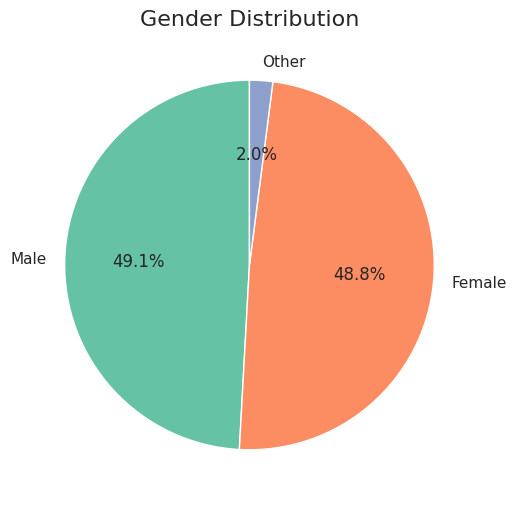

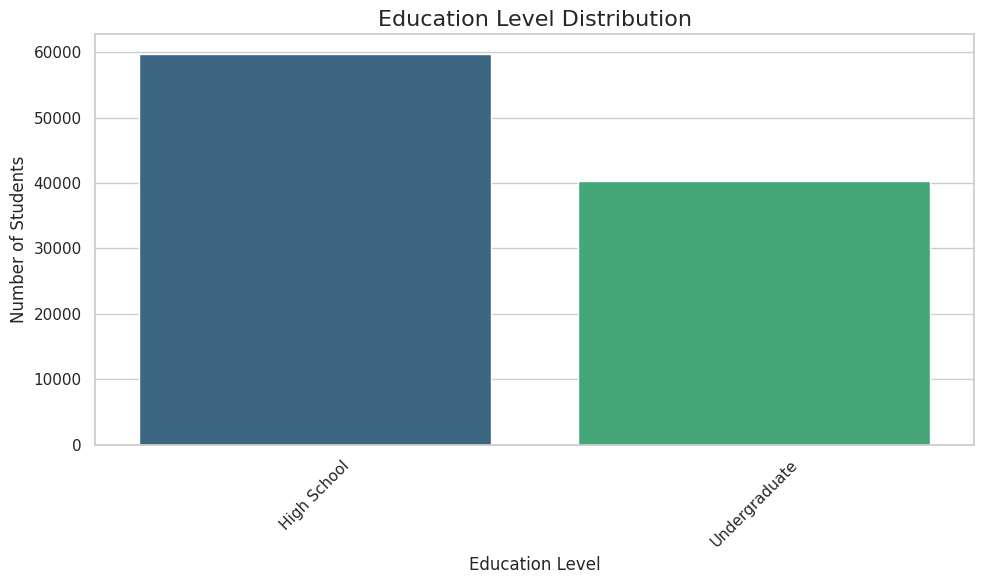

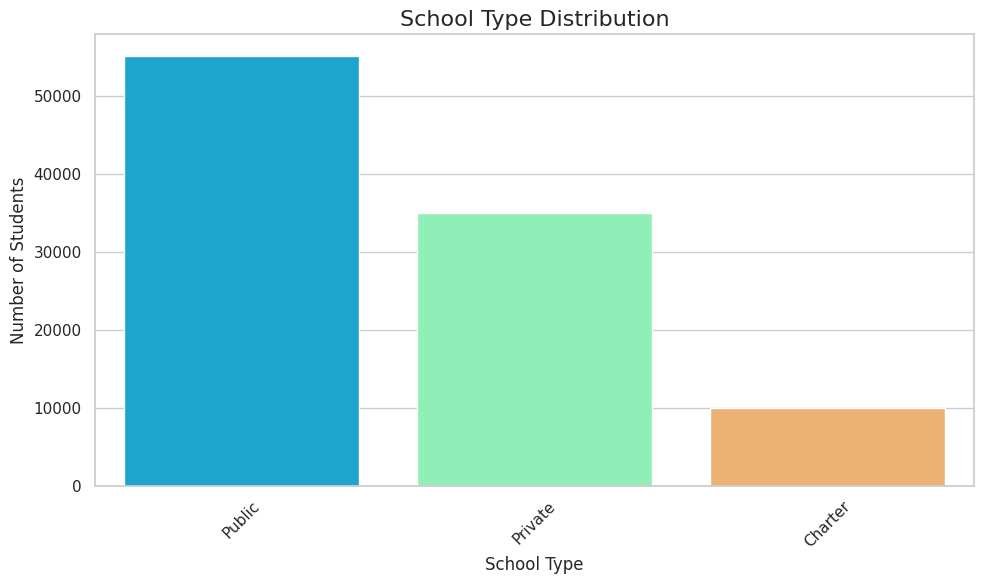

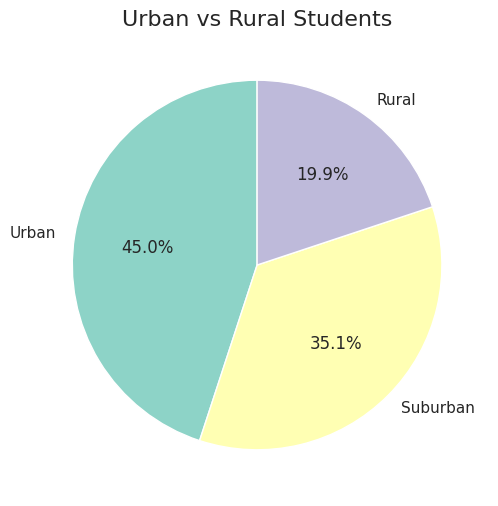

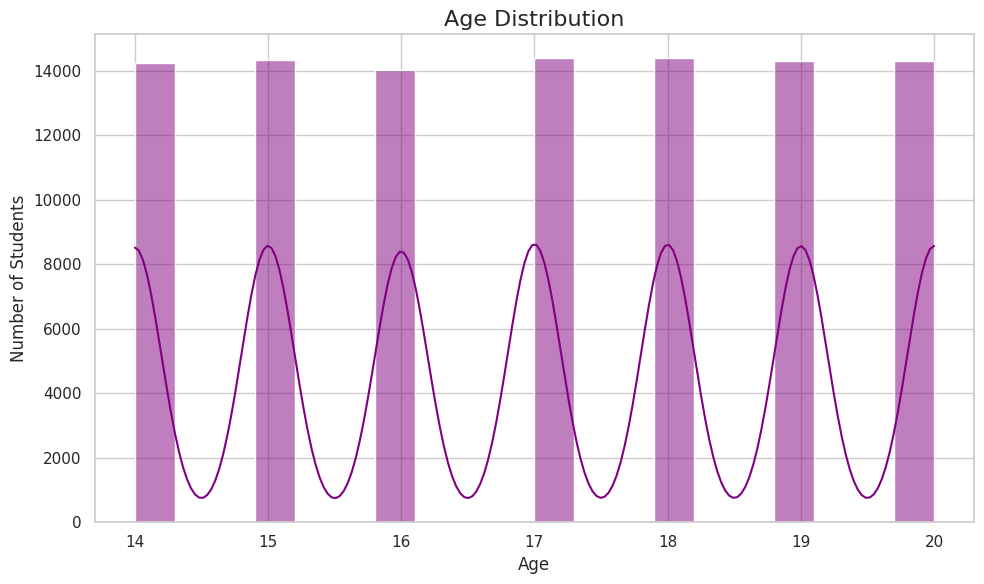

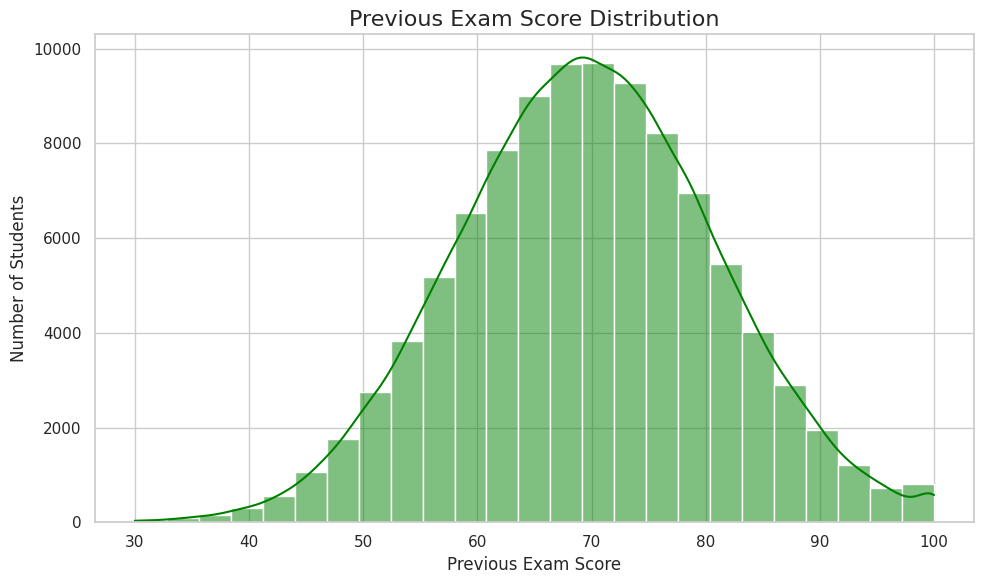

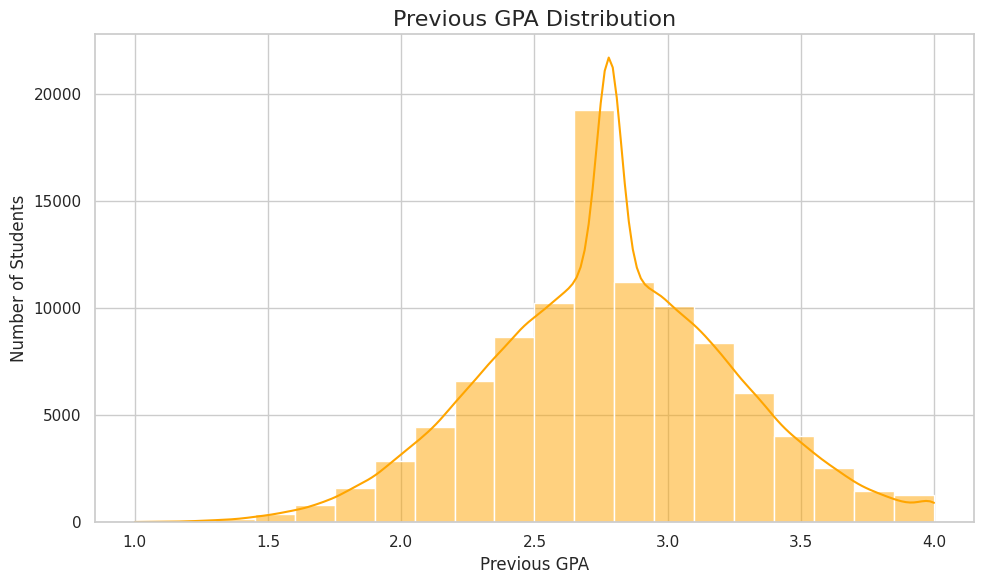

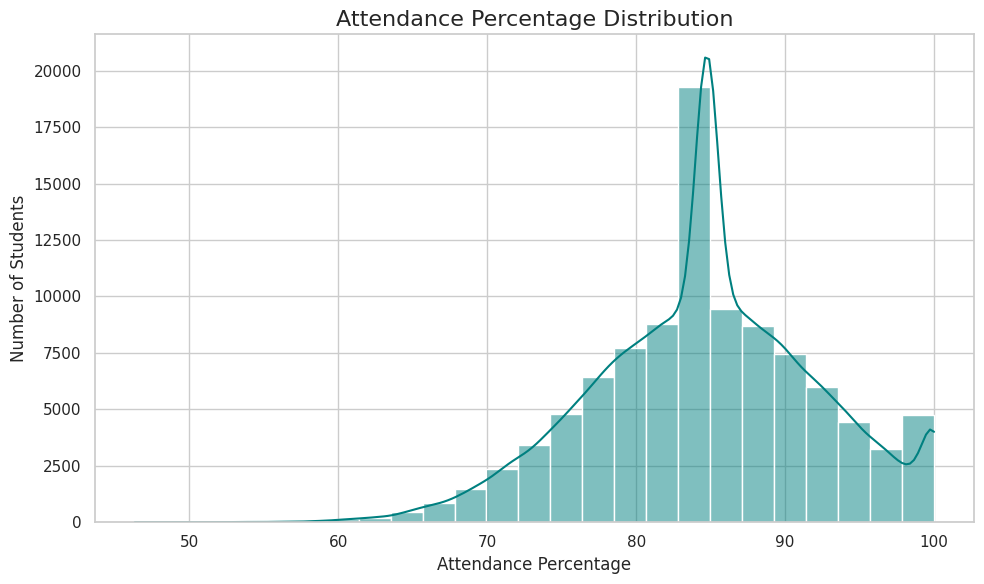

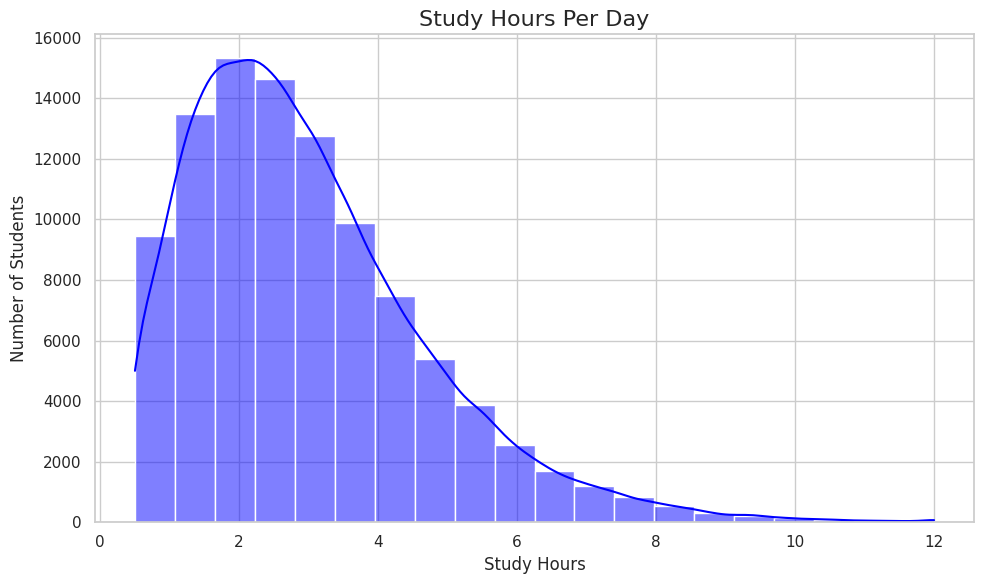

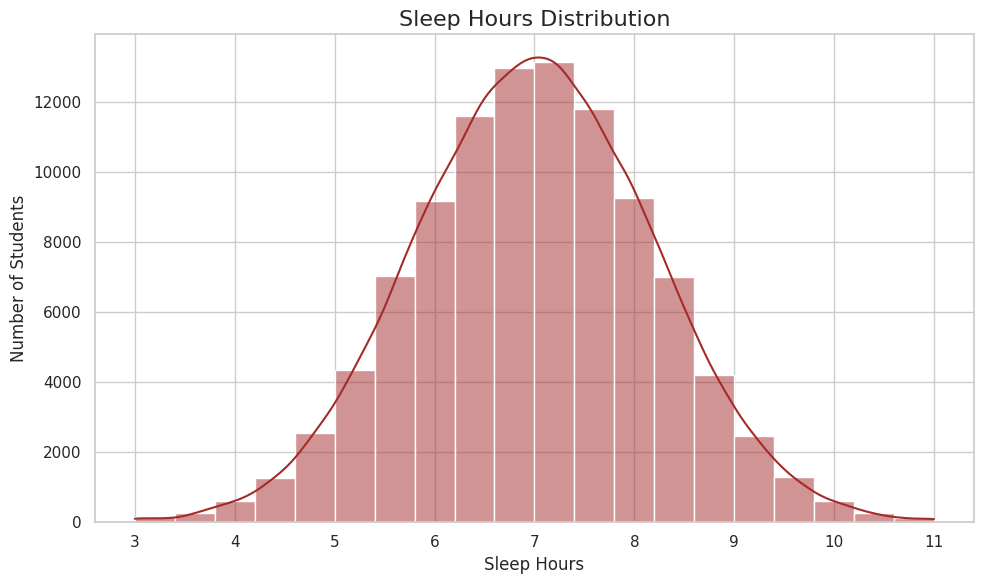

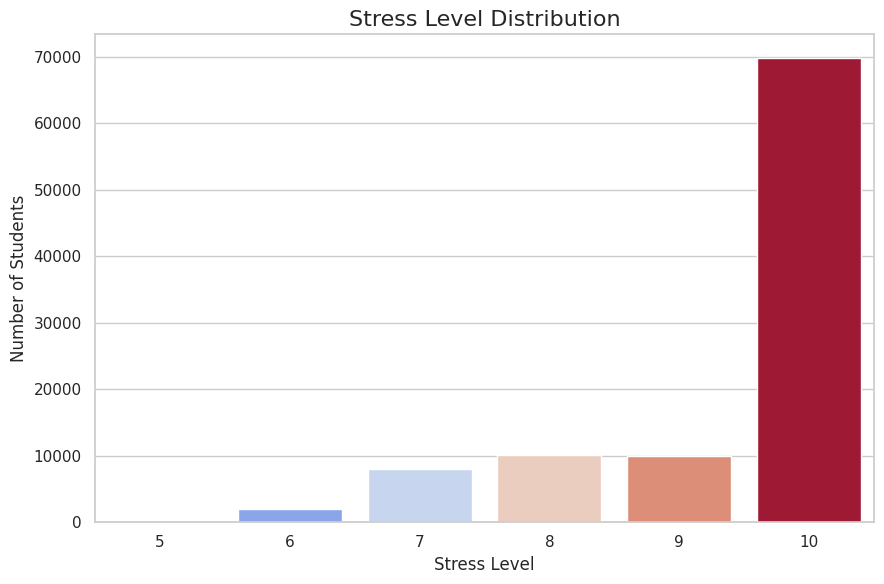

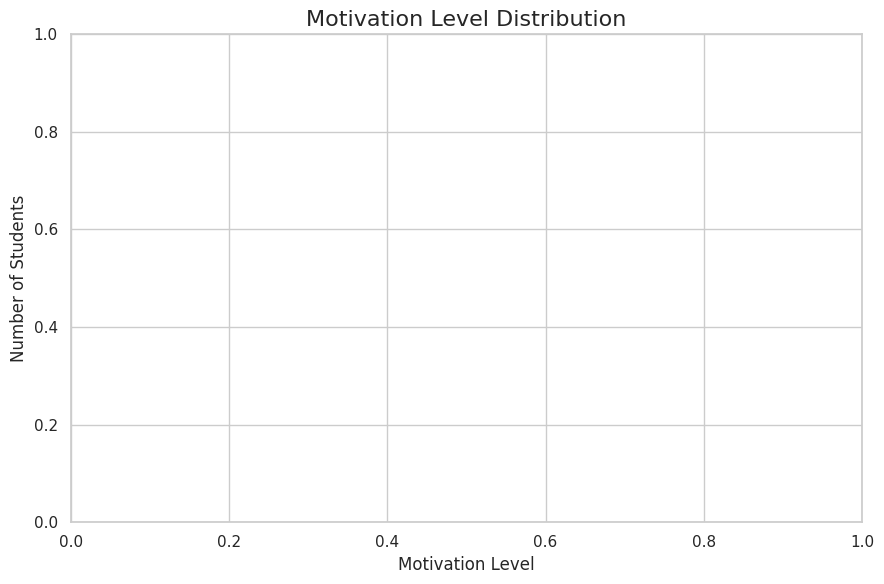

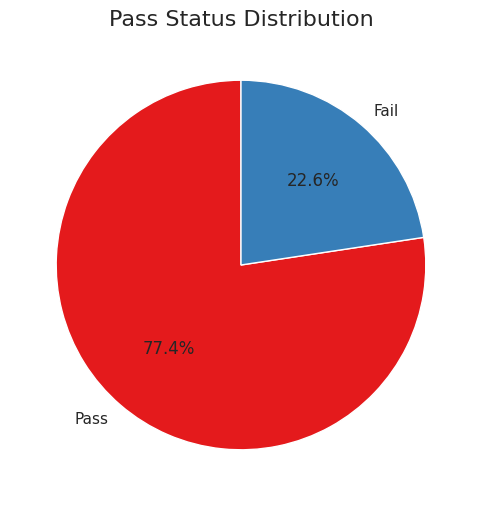

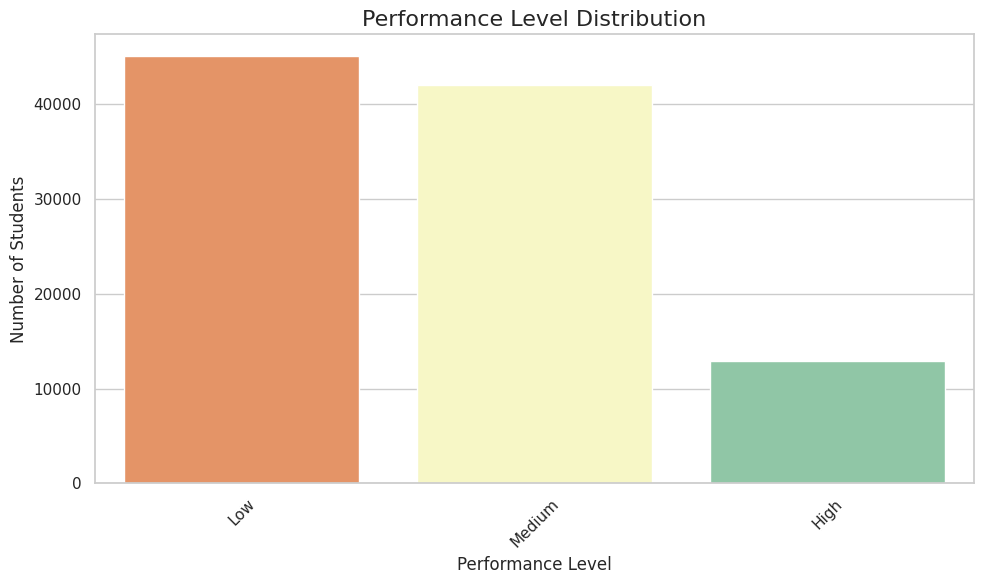

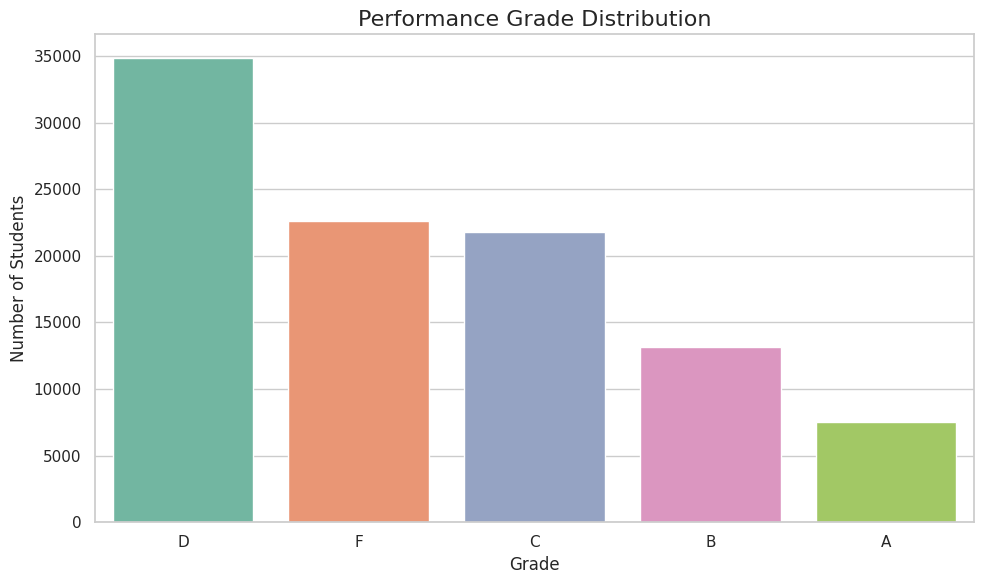

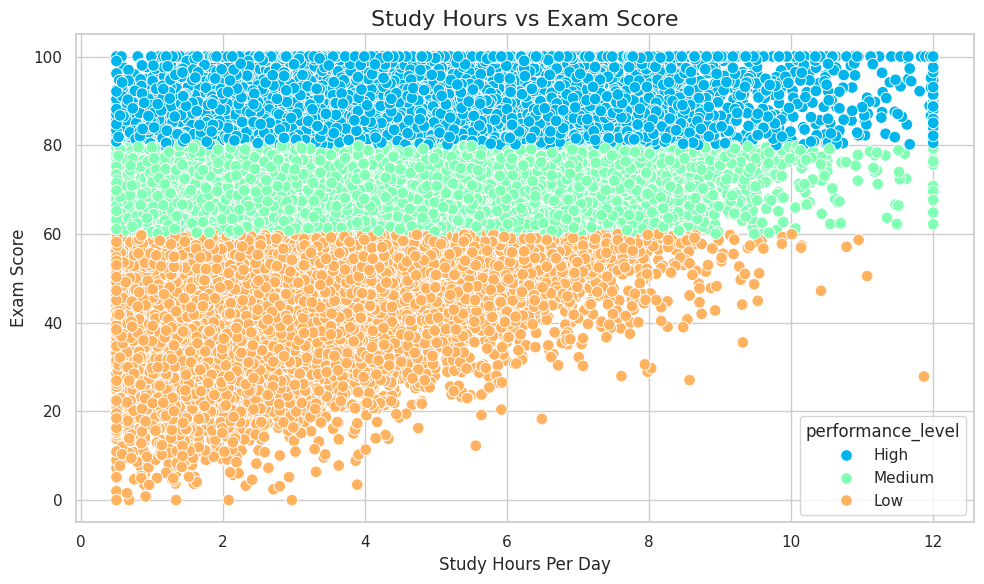

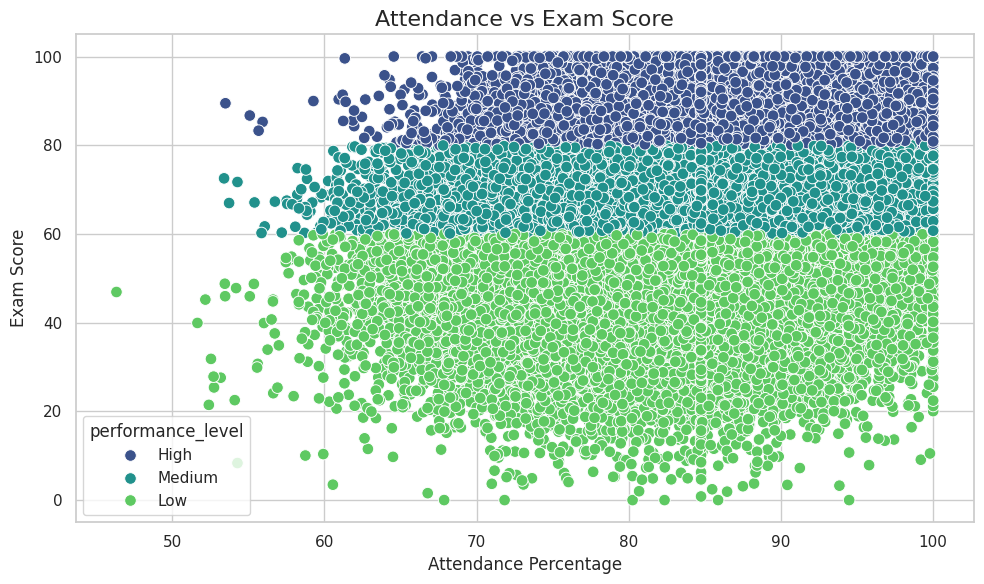

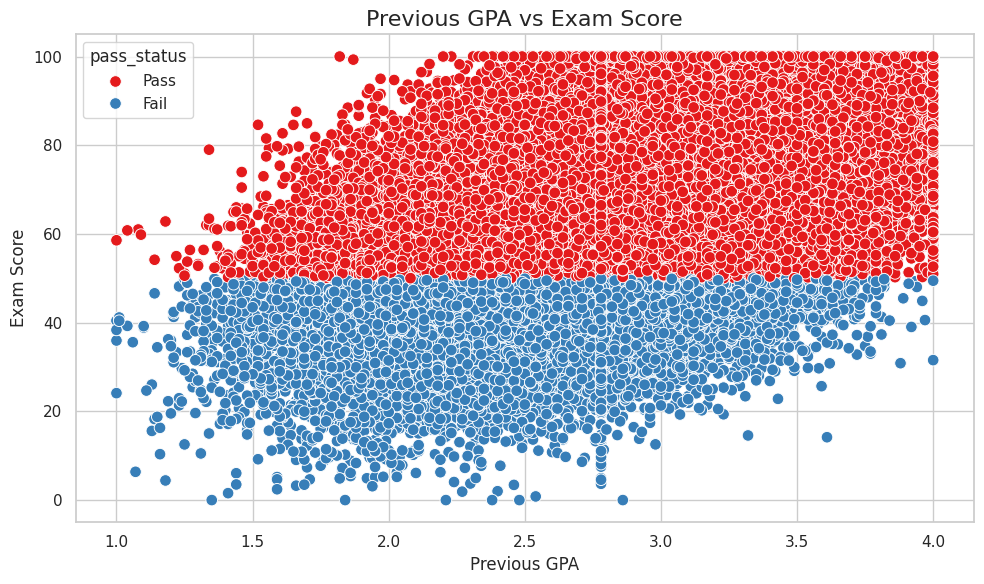

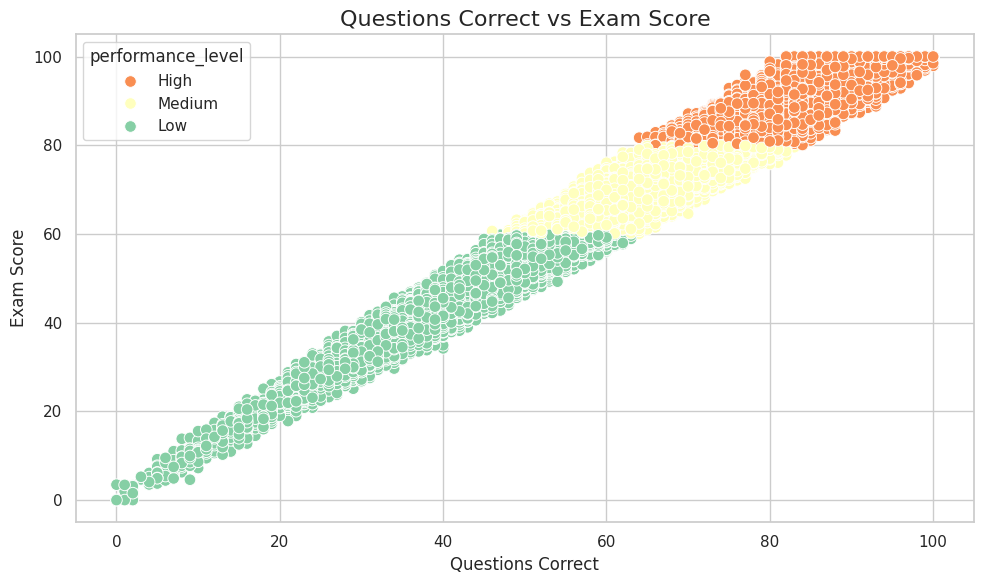

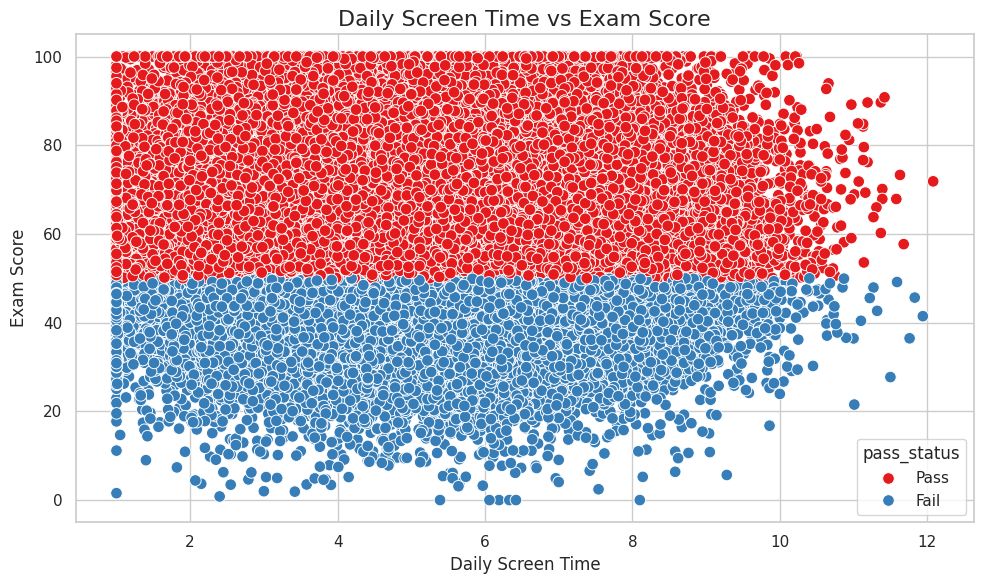

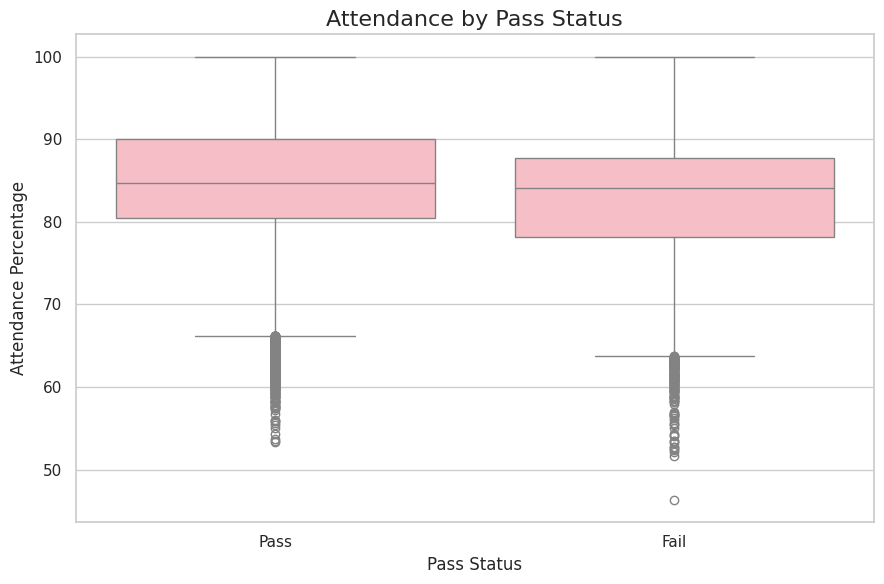

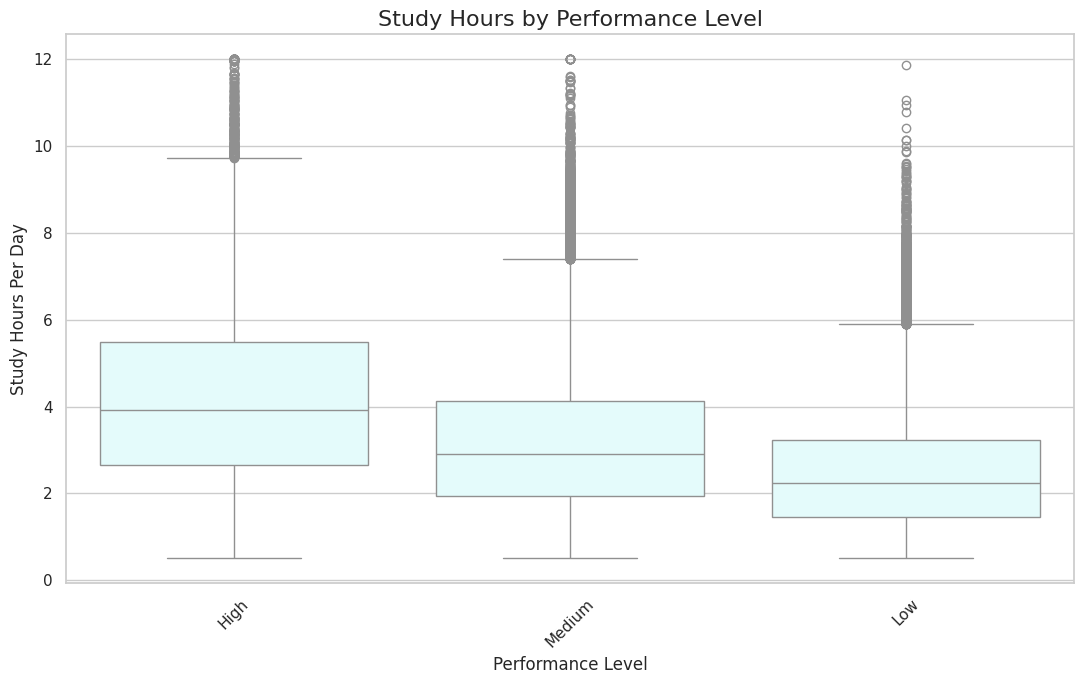

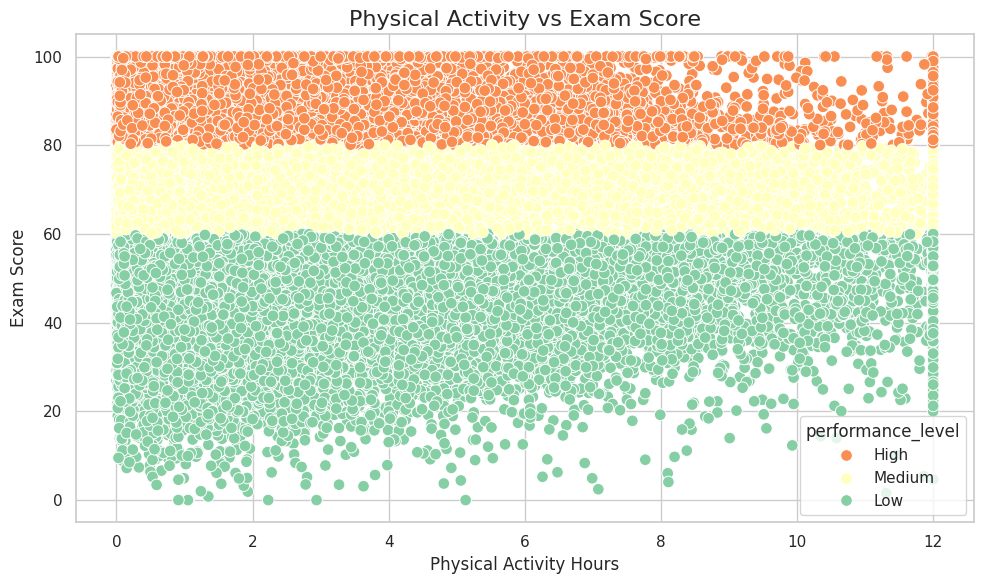

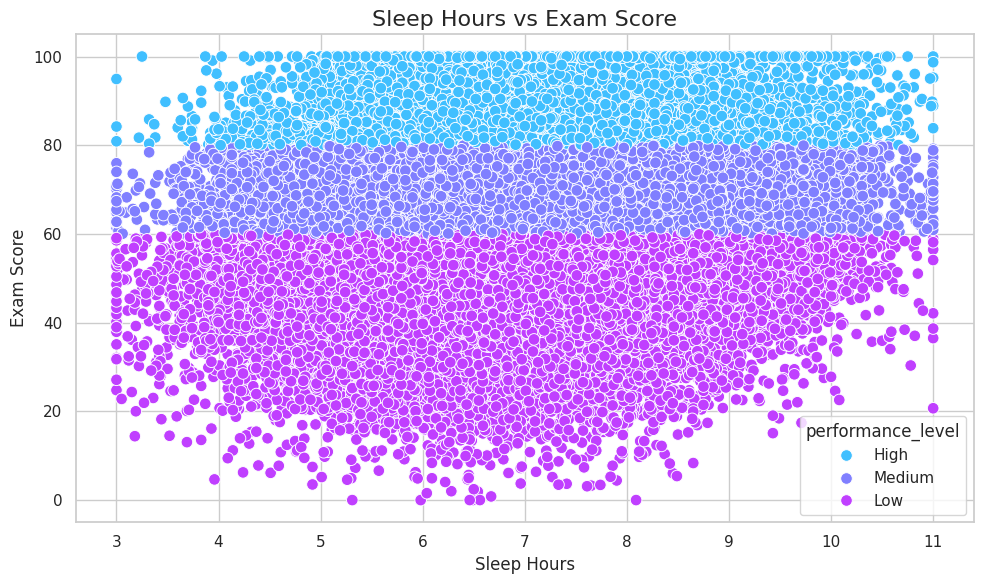

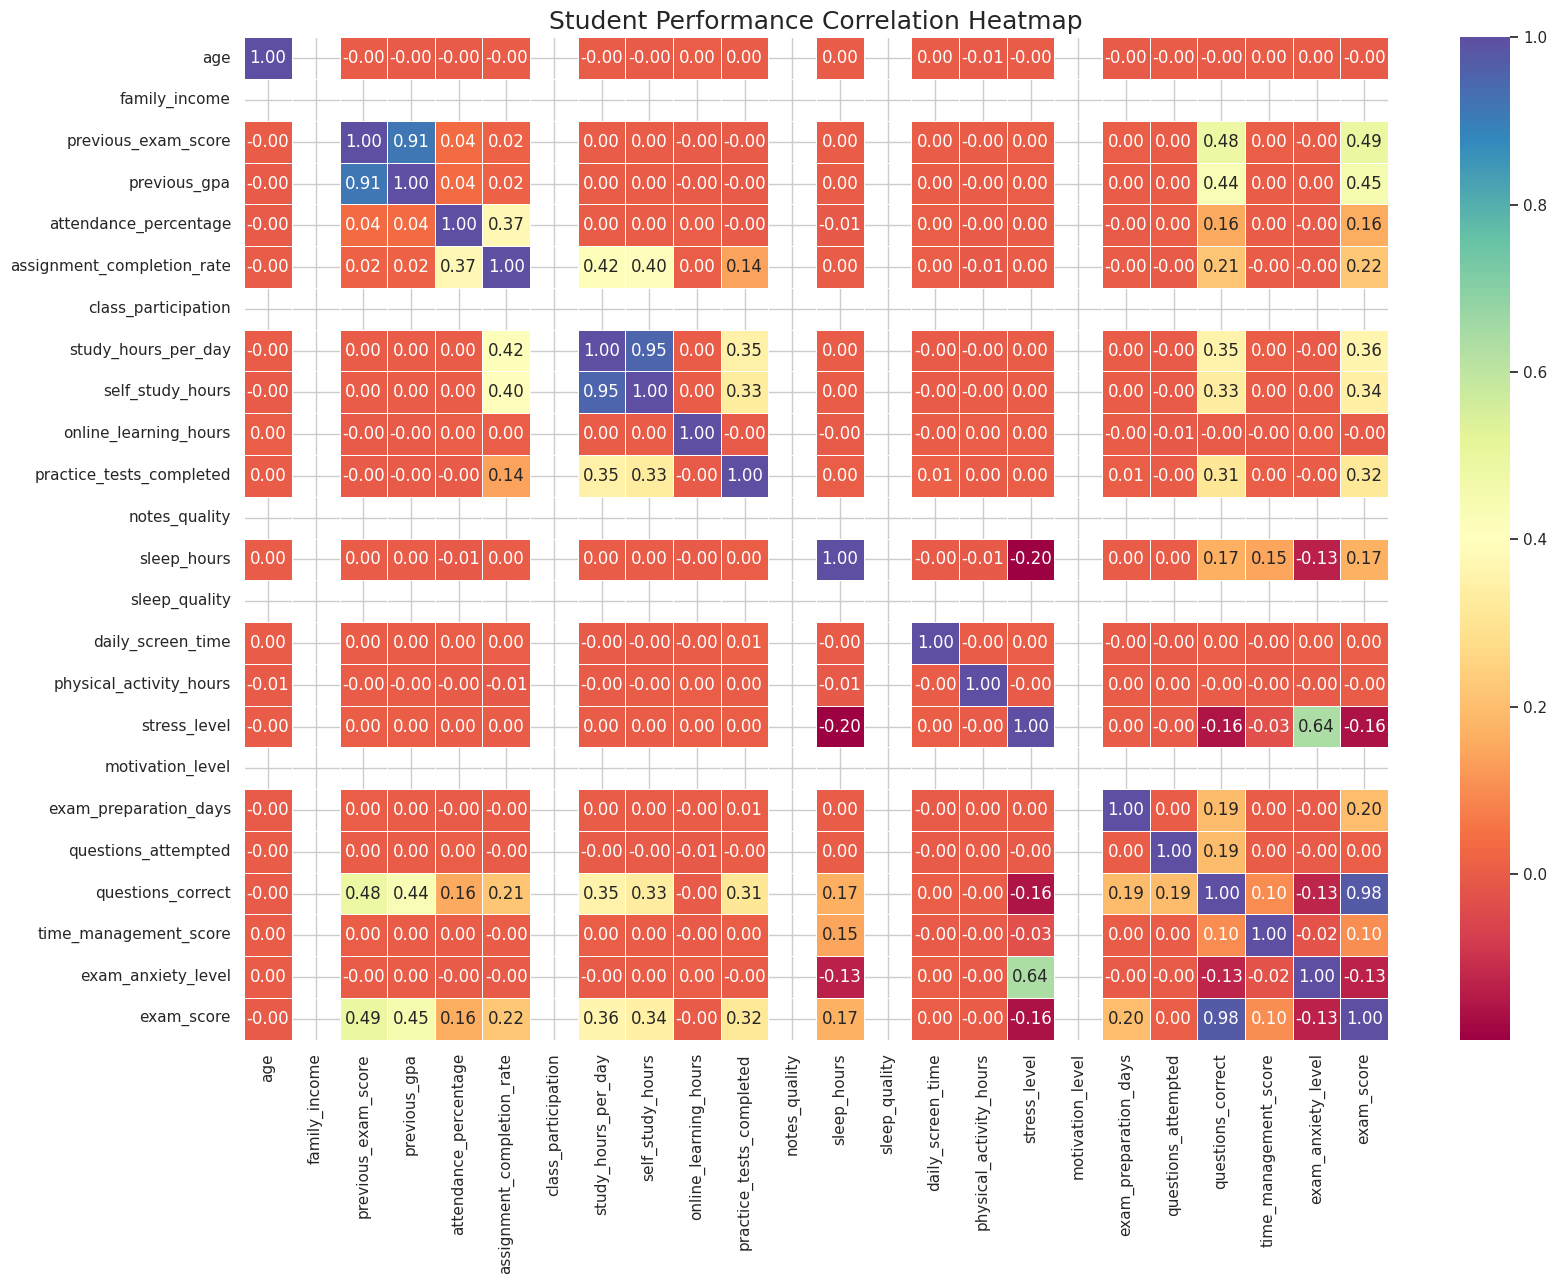


CORRELATION WITH EXAM SCORE
exam_score                    1.000000
questions_correct             0.975310
previous_exam_score           0.494438
previous_gpa                  0.449751
study_hours_per_day           0.363243
self_study_hours              0.342955
practice_tests_completed      0.316475
assignment_completion_rate    0.221118
exam_preparation_days         0.198577
sleep_hours                   0.170600
attendance_percentage         0.160720
time_management_score         0.101569
daily_screen_time             0.004760
questions_attempted           0.003539
physical_activity_hours      -0.000309
online_learning_hours        -0.002573
age                          -0.003493
exam_anxiety_level           -0.129932
stress_level                 -0.162345
family_income                      NaN
class_participation                NaN
notes_quality                      NaN
sleep_quality                      NaN
motivation_level                   NaN
Name: exam_score, dtype: float64


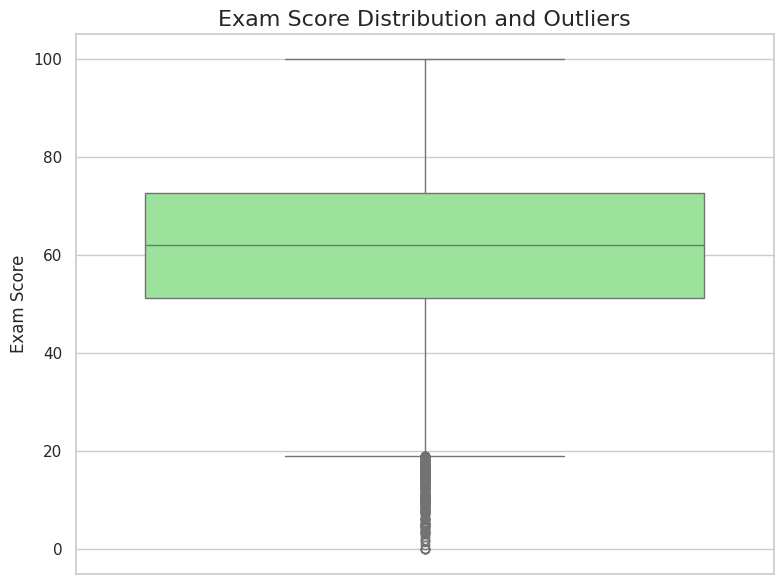


VISUALIZATION COMPLETED SUCCESSFULLY
Rows: 100000
Columns: 44
Remaining NULL values: 800000


In [13]:
# ============================================================
# STUDENT PERFORMANCE DATASET - EDA & VISUALIZATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. COPY DATA
# ------------------------------------------------------------

data = df.copy()

# Clean column names
data.columns = data.columns.str.strip()

print("Dataset Shape:", data.shape)

# ------------------------------------------------------------
# 2. CONVERT NUMERICAL COLUMNS
# ------------------------------------------------------------

numeric_columns = [
    'age',
    'family_income',
    'parent_education',
    'previous_exam_score',
    'previous_gpa',
    'attendance_percentage',
    'assignment_completion_rate',
    'class_participation',
    'study_hours_per_day',
    'self_study_hours',
    'online_learning_hours',
    'practice_tests_completed',
    'notes_quality',
    'sleep_hours',
    'sleep_quality',
    'daily_screen_time',
    'physical_activity_hours',
    'break_frequency',
    'stress_level',
    'motivation_level',
    'educational_app_usage',
    'online_course_hours',
    'exam_preparation_days',
    'questions_attempted',
    'questions_correct',
    'time_management_score',
    'exam_anxiety_level',
    'exam_score'
]

for col in numeric_columns:
    if col in data.columns:
        data[col] = pd.to_numeric(
            data[col],
            errors='coerce'
        )

# ------------------------------------------------------------
# 3. HANDLE NULL VALUES
# ------------------------------------------------------------

for col in numeric_columns:
    if col in data.columns:
        data[col] = data[col].fillna(
            data[col].median()
        )

categorical_columns = [
    'gender',
    'education_level',
    'school_type',
    'urban_rural',
    'study_consistency',
    'study_environment',
    'study_method',
    'revision_frequency',
    'private_tuition',
    'internet_access',
    'device_availability',
    'exam_difficulty',
    'performance_grade',
    'pass_status',
    'performance_level'
]

for col in categorical_columns:
    if col in data.columns:
        mode_value = data[col].mode()

        if len(mode_value) > 0:
            data[col] = data[col].fillna(
                mode_value.iloc[0]
            )
        else:
            data[col] = data[col].fillna(
                'Unknown'
            )

# ------------------------------------------------------------
# 4. REMOVE DUPLICATES
# ------------------------------------------------------------

print("Duplicates:", data.duplicated().sum())

data = data.drop_duplicates().reset_index(drop=True)

print("Shape after duplicates:", data.shape)

# ------------------------------------------------------------
# 5. VISUALIZATION STYLE
# ------------------------------------------------------------

sns.set_theme(style="whitegrid")

# ============================================================
# 6. GENDER DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 6))

gender_count = data['gender'].value_counts()

plt.pie(
    gender_count.values,
    labels=gender_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette(
        'Set2',
        len(gender_count)
    )
)

plt.title(
    'Gender Distribution',
    fontsize=16
)

plt.show()


# ============================================================
# 7. EDUCATION LEVEL
# ============================================================

plt.figure(figsize=(10, 6))

education_count = data[
    'education_level'
].value_counts()

sns.barplot(
    x=education_count.index,
    y=education_count.values,
    hue=education_count.index,
    palette='viridis',
    legend=False
)

plt.title(
    'Education Level Distribution',
    fontsize=16
)

plt.xlabel('Education Level')
plt.ylabel('Number of Students')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 8. SCHOOL TYPE
# ============================================================

plt.figure(figsize=(10, 6))

school_count = data[
    'school_type'
].value_counts()

sns.barplot(
    x=school_count.index,
    y=school_count.values,
    hue=school_count.index,
    palette='rainbow',
    legend=False
)

plt.title(
    'School Type Distribution',
    fontsize=16
)

plt.xlabel('School Type')
plt.ylabel('Number of Students')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 9. URBAN VS RURAL
# ============================================================

plt.figure(figsize=(8, 6))

location_count = data[
    'urban_rural'
].value_counts()

plt.pie(
    location_count.values,
    labels=location_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette(
        'Set3',
        len(location_count)
    )
)

plt.title(
    'Urban vs Rural Students',
    fontsize=16
)

plt.show()


# ============================================================
# 10. AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data['age'],
    bins=20,
    kde=True,
    color='purple'
)

plt.title(
    'Age Distribution',
    fontsize=16
)

plt.xlabel('Age')
plt.ylabel('Number of Students')

plt.tight_layout()
plt.show()


# ============================================================
# 11. PREVIOUS EXAM SCORE
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data['previous_exam_score'],
    bins=25,
    kde=True,
    color='green'
)

plt.title(
    'Previous Exam Score Distribution',
    fontsize=16
)

plt.xlabel('Previous Exam Score')
plt.ylabel('Number of Students')

plt.tight_layout()
plt.show()


# ============================================================
# 12. GPA DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data['previous_gpa'],
    bins=20,
    kde=True,
    color='orange'
)

plt.title(
    'Previous GPA Distribution',
    fontsize=16
)

plt.xlabel('Previous GPA')
plt.ylabel('Number of Students')

plt.tight_layout()
plt.show()


# ============================================================
# 13. ATTENDANCE
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data['attendance_percentage'],
    bins=25,
    kde=True,
    color='teal'
)

plt.title(
    'Attendance Percentage Distribution',
    fontsize=16
)

plt.xlabel('Attendance Percentage')
plt.ylabel('Number of Students')

plt.tight_layout()
plt.show()


# ============================================================
# 14. STUDY HOURS
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data['study_hours_per_day'],
    bins=20,
    kde=True,
    color='blue'
)

plt.title(
    'Study Hours Per Day',
    fontsize=16
)

plt.xlabel('Study Hours')
plt.ylabel('Number of Students')

plt.tight_layout()
plt.show()


# ============================================================
# 15. SLEEP HOURS
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data['sleep_hours'],
    bins=20,
    kde=True,
    color='brown'
)

plt.title(
    'Sleep Hours Distribution',
    fontsize=16
)

plt.xlabel('Sleep Hours')
plt.ylabel('Number of Students')

plt.tight_layout()
plt.show()


# ============================================================
# 16. STRESS LEVEL
# ============================================================

plt.figure(figsize=(9, 6))

stress_count = data[
    'stress_level'
].value_counts().sort_index()

sns.barplot(
    x=stress_count.index,
    y=stress_count.values,
    hue=stress_count.index,
    palette='coolwarm',
    legend=False
)

plt.title(
    'Stress Level Distribution',
    fontsize=16
)

plt.xlabel('Stress Level')
plt.ylabel('Number of Students')

plt.tight_layout()
plt.show()


# ============================================================
# 17. MOTIVATION LEVEL
# ============================================================

plt.figure(figsize=(9, 6))

motivation_count = data[
    'motivation_level'
].value_counts().sort_index()

sns.barplot(
    x=motivation_count.index,
    y=motivation_count.values,
    hue=motivation_count.index,
    palette='plasma',
    legend=False
)

plt.title(
    'Motivation Level Distribution',
    fontsize=16
)

plt.xlabel('Motivation Level')
plt.ylabel('Number of Students')

plt.tight_layout()
plt.show()


# ============================================================
# 18. PASS STATUS
# ============================================================

plt.figure(figsize=(8, 6))

pass_count = data[
    'pass_status'
].value_counts()

plt.pie(
    pass_count.values,
    labels=pass_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette(
        'Set1',
        len(pass_count)
    )
)

plt.title(
    'Pass Status Distribution',
    fontsize=16
)

plt.show()


# ============================================================
# 19. PERFORMANCE LEVEL
# ============================================================

plt.figure(figsize=(10, 6))

performance_count = data[
    'performance_level'
].value_counts()

sns.barplot(
    x=performance_count.index,
    y=performance_count.values,
    hue=performance_count.index,
    palette='Spectral',
    legend=False
)

plt.title(
    'Performance Level Distribution',
    fontsize=16
)

plt.xlabel('Performance Level')
plt.ylabel('Number of Students')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 20. PERFORMANCE GRADE
# ============================================================

plt.figure(figsize=(10, 6))

grade_count = data[
    'performance_grade'
].value_counts()

sns.barplot(
    x=grade_count.index,
    y=grade_count.values,
    hue=grade_count.index,
    palette='Set2',
    legend=False
)

plt.title(
    'Performance Grade Distribution',
    fontsize=16
)

plt.xlabel('Grade')
plt.ylabel('Number of Students')

plt.tight_layout()
plt.show()


# ============================================================
# 21. STUDY HOURS VS EXAM SCORE
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x='study_hours_per_day',
    y='exam_score',
    hue='performance_level',
    palette='rainbow',
    s=70
)

plt.title(
    'Study Hours vs Exam Score',
    fontsize=16
)

plt.xlabel('Study Hours Per Day')
plt.ylabel('Exam Score')

plt.tight_layout()
plt.show()


# ============================================================
# 22. ATTENDANCE VS EXAM SCORE
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x='attendance_percentage',
    y='exam_score',
    hue='performance_level',
    palette='viridis',
    s=70
)

plt.title(
    'Attendance vs Exam Score',
    fontsize=16
)

plt.xlabel('Attendance Percentage')
plt.ylabel('Exam Score')

plt.tight_layout()
plt.show()


# ============================================================
# 23. PREVIOUS GPA VS EXAM SCORE
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x='previous_gpa',
    y='exam_score',
    hue='pass_status',
    palette='Set1',
    s=70
)

plt.title(
    'Previous GPA vs Exam Score',
    fontsize=16
)

plt.xlabel('Previous GPA')
plt.ylabel('Exam Score')

plt.tight_layout()
plt.show()


# ============================================================
# 24. QUESTIONS CORRECT VS EXAM SCORE
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x='questions_correct',
    y='exam_score',
    hue='performance_level',
    palette='Spectral',
    s=70
)

plt.title(
    'Questions Correct vs Exam Score',
    fontsize=16
)

plt.xlabel('Questions Correct')
plt.ylabel('Exam Score')

plt.tight_layout()
plt.show()


# ============================================================
# 25. SCREEN TIME VS EXAM SCORE
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x='daily_screen_time',
    y='exam_score',
    hue='pass_status',
    palette='Set1',
    s=70
)

plt.title(
    'Daily Screen Time vs Exam Score',
    fontsize=16
)

plt.xlabel('Daily Screen Time')
plt.ylabel('Exam Score')

plt.tight_layout()
plt.show()








# ============================================================
# 31. ATTENDANCE BY PASS STATUS
# ============================================================

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=data,
    x='pass_status',
    y='attendance_percentage',
    color='lightpink'
)

plt.title(
    'Attendance by Pass Status',
    fontsize=16
)

plt.xlabel('Pass Status')
plt.ylabel('Attendance Percentage')

plt.tight_layout()
plt.show()


# ============================================================
# 32. STUDY HOURS BY PERFORMANCE
# ============================================================

plt.figure(figsize=(11, 7))

sns.boxplot(
    data=data,
    x='performance_level',
    y='study_hours_per_day',
    color='lightcyan'
)

plt.title(
    'Study Hours by Performance Level',
    fontsize=16
)

plt.xlabel('Performance Level')
plt.ylabel('Study Hours Per Day')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 33. PHYSICAL ACTIVITY VS EXAM SCORE
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x='physical_activity_hours',
    y='exam_score',
    hue='performance_level',
    palette='Spectral',
    s=70
)

plt.title(
    'Physical Activity vs Exam Score',
    fontsize=16
)

plt.xlabel('Physical Activity Hours')
plt.ylabel('Exam Score')

plt.tight_layout()
plt.show()


# ============================================================
# 34. SLEEP VS EXAM SCORE
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x='sleep_hours',
    y='exam_score',
    hue='performance_level',
    palette='cool',
    s=70
)

plt.title(
    'Sleep Hours vs Exam Score',
    fontsize=16
)

plt.xlabel('Sleep Hours')
plt.ylabel('Exam Score')

plt.tight_layout()
plt.show()


# ============================================================
# 35. CORRELATION HEATMAP
# ============================================================

corr_columns = [
    'age',
    'family_income',
    'previous_exam_score',
    'previous_gpa',
    'attendance_percentage',
    'assignment_completion_rate',
    'class_participation',
    'study_hours_per_day',
    'self_study_hours',
    'online_learning_hours',
    'practice_tests_completed',
    'notes_quality',
    'sleep_hours',
    'sleep_quality',
    'daily_screen_time',
    'physical_activity_hours',
    'stress_level',
    'motivation_level',
    'exam_preparation_days',
    'questions_attempted',
    'questions_correct',
    'time_management_score',
    'exam_anxiety_level',
    'exam_score'
]

corr_columns = [
    col for col in corr_columns
    if col in data.columns
]

correlation = data[
    corr_columns
].corr()

plt.figure(figsize=(17, 13))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='Spectral',
    linewidths=0.5
)

plt.title(
    'Student Performance Correlation Heatmap',
    fontsize=18
)

plt.tight_layout()
plt.show()


# ============================================================
# 36. TOP CORRELATIONS WITH EXAM SCORE
# ============================================================

score_correlation = correlation[
    'exam_score'
].sort_values(
    ascending=False
)

print("\n" + "=" * 60)
print("CORRELATION WITH EXAM SCORE")
print("=" * 60)

print(score_correlation)


# ============================================================
# 37. EXAM SCORE BOXPLOT
# ============================================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    y='exam_score',
    color='lightgreen'
)

plt.title(
    'Exam Score Distribution and Outliers',
    fontsize=16
)

plt.ylabel('Exam Score')

plt.tight_layout()
plt.show()


# ============================================================
# 38. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("VISUALIZATION COMPLETED SUCCESSFULLY")
print("=" * 70)

print("Rows:", data.shape[0])
print("Columns:", data.shape[1])
print(
    "Remaining NULL values:",
    data.isnull().sum().sum()
)

## Features Engineering

In [14]:
# ============================================================
# STUDENT PERFORMANCE - TRAIN TEST + ACCURACY
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


# ============================================================
# 1. COPY DATA
# ============================================================

data = df.copy()

# Remove extra spaces from column names
data.columns = data.columns.str.strip()

print("Dataset Shape:", data.shape)


# ============================================================
# 2. TARGET COLUMN
# ============================================================

target = "pass_status"


# Remove rows where target is missing
data = data.dropna(subset=[target]).reset_index(drop=True)


# ============================================================
# 3. REMOVE DATA LEAKAGE
# ============================================================

# These columns directly represent final performance.
# They should NOT be used to predict pass_status.

drop_columns = [
    "student_id",
    "exam_score",
    "performance_grade",
    "performance_level",
    "pass_status"
]

drop_columns = [
    col for col in drop_columns
    if col in data.columns
]


# ============================================================
# 4. FEATURES AND TARGET
# ============================================================

X = data.drop(columns=drop_columns)
y = data[target]


# ============================================================
# 5. CONVERT TARGET TO NUMERIC
# ============================================================

if y.dtype == "object":

    y = y.astype(str).str.strip()

    mapping = {
        "Pass": 1,
        "Fail": 0,
        "pass": 1,
        "fail": 0,
        "Passed": 1,
        "Failed": 0,
        "passed": 1,
        "failed": 0,
        "Yes": 1,
        "No": 0,
        "yes": 1,
        "no": 0
    }

    converted_y = y.map(mapping)

    # If mapping successfully converted the values
    if converted_y.notna().all():
        y = converted_y

    else:
        # Automatic encoding for unexpected categorical values
        y = pd.factorize(y)[0]


# ============================================================
# 6. IDENTIFY NUMERICAL COLUMNS
# ============================================================

numeric_features = X.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()


# ============================================================
# 7. IDENTIFY CATEGORICAL COLUMNS
# ============================================================

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


print("\nNumerical Features:", len(numeric_features))
print("Categorical Features:", len(categorical_features))


# ============================================================
# 8. NUMERICAL PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)


# ============================================================
# 9. CATEGORICAL PREPROCESSING
# ============================================================

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# ============================================================
# 10. PREPROCESSOR
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)


# ============================================================
# 11. TRAIN TEST SPLIT
# ============================================================

class_counts = y.value_counts()

if len(class_counts) > 1 and class_counts.min() >= 2:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

else:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )


print("\n========================================")
print("TRAIN TEST SPLIT")
print("========================================")

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)


# ============================================================
# 12. RANDOM FOREST CLASSIFIER
# ============================================================

model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)


# ============================================================
# 13. TRAIN MODEL
# ============================================================

print("\nTraining model...")

model.fit(
    X_train,
    y_train
)

print("Training completed!")


# ============================================================
# 14. PREDICTION
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 15. ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n========================================")
print("MODEL ACCURACY")
print("========================================")

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)


# ============================================================
# 16. TRAINING ACCURACY
# ============================================================

train_pred = model.predict(X_train)

train_accuracy = accuracy_score(
    y_train,
    train_pred
)

print(
    f"Training Accuracy: {train_accuracy * 100:.2f}%"
)

print(
    f"Testing Accuracy : {accuracy * 100:.2f}%"
)


# ============================================================
# 17. CLASSIFICATION REPORT
# ============================================================

print("\n========================================")
print("CLASSIFICATION REPORT")
print("========================================")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Dataset Shape: (100000, 44)

Numerical Features: 21
Categorical Features: 18

TRAIN TEST SPLIT
Training data: (80000, 39)
Testing data : (20000, 39)

Training model...
Training completed!

MODEL ACCURACY
Accuracy: 96.61%
Training Accuracy: 100.00%
Testing Accuracy : 96.61%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      4522
           1       0.98      0.98      0.98     15478

    accuracy                           0.97     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       0.97      0.97      0.97     20000



## Thanks...........Please Upvote